Data from https://open.toronto.ca/dataset/motor-vehicle-collisions-involving-killed-or-seriously-injured-persons/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load local file
df = pd.read_csv("Motor Vehicle Collisions with KSI Data - 4326.csv")
df

,_id,collision_id,accdate,stname1,stname2,stname3,per_inv,acclass,accloc,traffictl,...,distracted,cyclist,motorcyclist,other_micromobility,older_adult,pedestrian,red_light,school_child,heavy_truck,geometry
0,1,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Non-Fatal Injury,Intersection-Related,No Control,...,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959..."
1,2,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Non-Fatal Injury,Intersection-Related,No Control,...,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959..."
2,3,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Non-Fatal Injury,Intersection-Related,No Control,...,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959..."
3,4,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Non-Fatal Injury,Intersection-Related,No Control,...,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959..."
4,5,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Non-Fatal Injury,Intersection-Related,No Control,...,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20522,20523,2026:6001055451,2026-05-22T14:05:00,1150 DUFFERIN ST,SHANLY ST,25 m North of,5,Non-Fatal Injury,Non-Intersection,NaN,...,False,False,True,False,False,False,False,False,True,"{""coordinates"": [[-79.4369859595973, 43.663714..."
20523,20524,2026:6001055451,2026-05-22T14:05:00,1150 DUFFERIN ST,SHANLY ST,25 m North of,5,Non-Fatal Injury,Non-Intersection,NaN,...,False,False,True,False,False,False,False,False,True,"{""coordinates"": [[-79.4369859595973, 43.663714..."
20524,20525,2026:6001133854,2026-06-01T18:36:00,79 SHORNCLIFFE RD,NaN,NaN,1,Fatal Injury,Non-Intersection,NaN,...,False,False,False,False,False,False,False,False,False,"{""coordinates"": [[-79.54115120836634, 43.62365..."
20525,20526,2026:6001055451,2026-05-22T14:05:00,1150 DUFFERIN ST,SHANLY ST,25 m North of,5,Non-Fatal Injury,Non-Intersection,NaN,...,False,False,True,False,False,False,False,False,True,"{""coordinates"": [[-79.4369859595973, 43.663714..."


In [2]:
# Convert the accident date column to date format
df["accdate"] = pd.to_datetime(df["accdate"], errors="coerce")

# Keep only collisions from 2025
df_2025 = df[df["accdate"].dt.year == 2025]

# Keep only one row for each collision
unique_events_2025 = df_2025.drop_duplicates("collision_id")

# Check results
print("Total 2025 rows:", len(df_2025)) # compare with excel analysis
print("Unique 2025 events:", len(unique_events_2025)) # compare with excel analysis

Total 2025 rows: 611
Unique 2025 events: 252


In [4]:
# Count road surface conditions
rdsfcond_counts = unique_events_2025["rdsfcond"].fillna("Unknown").value_counts()
rdsfcond_counts

rdsfcond
Dry            205
Wet             38
Loose Snow       6
Packed Snow      1
Unknown          1
Slush            1
Name: count, dtype: int64

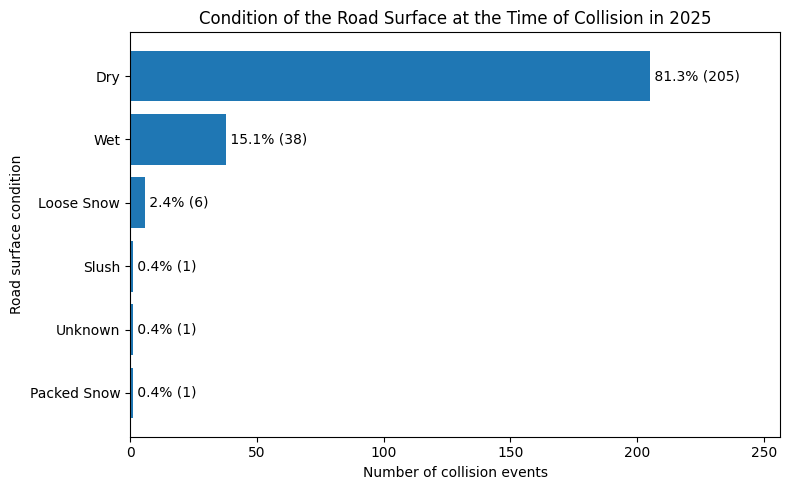

In [12]:
# Sort counts and calculate percentages
counts = rdsfcond_counts.sort_values()
percents = counts / counts.sum() * 100

# Bar Plot
plt.figure(figsize=(8, 5))

plt.barh(counts.index, counts.values)

for i in range(len(counts)):
    count = counts.values[i]
    pct = percents.values[i]
    plt.text(count, i, f" {pct:.1f}% ({count})", va="center")

plt.title("Condition of the Road Surface at the Time of Collision in 2025")
plt.xlabel("Number of collision events")
plt.ylabel("Road surface condition")
plt.xlim(0, counts.max() * 1.25) # improve

plt.tight_layout()

# Save visualization
path = 'C:/Users/yangy/OneDrive/桌面/DSI/visualization/02_activities/assignments/assignment3' # can be full path or relative path
filename = '/assignment3_viz1.png'
plt.savefig(path+filename, dpi=300)

plt.show()

In [10]:
# Save visualization
path = 'C:/Users/yangy/OneDrive/桌面/DSI/visualization/02_activities/assignments/assignment3' # can be full path or relative path
filename = 'assignment3_viz1.png'
plt.savefig(path+filename, dpi=300)

<Figure size 640x480 with 0 Axes>